<a href="https://colab.research.google.com/github/ArtemNyow/university-Deep-Learning-lb/blob/main/lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.2482 - loss: 2.2309 - val_accuracy: 0.6778 - val_loss: 1.7491
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6936 - loss: 1.4352 - val_accuracy: 0.8833 - val_loss: 0.5847
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8483 - loss: 0.5873 - val_accuracy: 0.9250 - val_loss: 0.2910
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9137 - loss: 0.3345 - val_accuracy: 0.9361 - val_loss: 0.2023
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9270 - loss: 0.2404 - val_accuracy: 0.9472 - val_loss: 0.1758
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9396 - loss: 0.2135 - val_accuracy: 0.9583 - val_loss: 0.1434
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9628 - loss: 0.1547 - val_accuracy: 0.9667 - val_loss: 0.1155
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9664 - loss: 0.1281 - val_accuracy: 0.9750 - val_loss: 0.0941
Epo

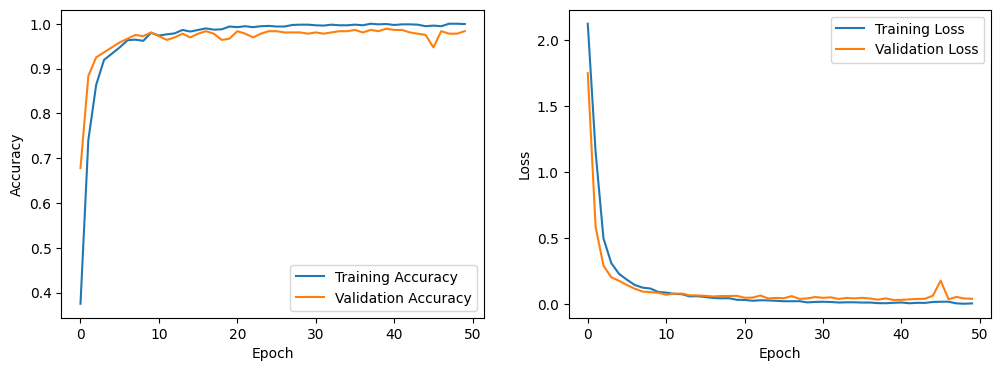

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9816 - loss: 0.0411 
Test Accuracy: 0.9833
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


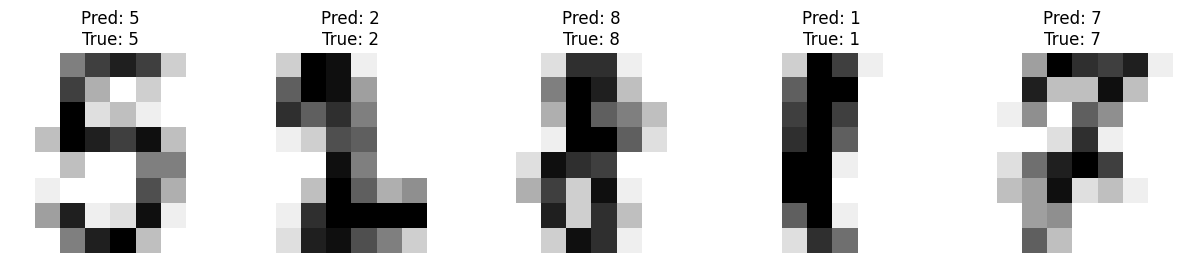

In [ ]:
# Імпорт бібліотек
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import TensorBoard
from datetime import datetime

# 1. Завантаження даних
digits = datasets.load_digits()
X = digits.images  # Масив 8x8 зі значеннями пікселів 0-16
y = digits.target  # Мітки (0-9)

# 2. Попередня обробка
# Нормалізація пікселів до [0, 1] та додавання каналу (для CNN)
X = X.reshape(-1, 8, 8, 1) / 16.0

# Розділення на тренувальний та тестовий набори
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 3. Побудова моделі CNN
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(8, 8, 1), name='conv1'),
    MaxPooling2D((2, 2), name='pool1'),
    Conv2D(64, (3, 3), activation='relu', name='conv2'),
    Flatten(),
    Dense(128, activation='relu', name='dense1'),
    Dropout(0.2),
    Dense(10, activation='softmax', name='output')
])

# 4. Компіляція моделі
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Налаштування TensorBoard
logdir = "logs/" + datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=logdir)

# 6. Навчання моделі
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[tensorboard_callback]
)

# 7. Візуалізація результатів
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 8. Оцінка моделі
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

# 9. Візуалізація прогнозів
sample_images = X_test[:5]
predictions = model.predict(sample_images)
predicted_labels = np.argmax(predictions, axis=1)

plt.figure(figsize=(15, 3))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(sample_images[i].reshape(8, 8), cmap='gray_r')
    plt.title(f"Pred: {predicted_labels[i]}\nTrue: {y_test[i]}")
    plt.axis('off')
plt.show()